In [28]:
import numpy as np
import torch
import torch.nn as nn
from matplotlib import pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, StratifiedKFold
from torch.utils.data.dataloader import DataLoader
from torch.utils.data.dataset import TensorDataset

import optuna

plt.style.use("default")

In [29]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [30]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False) # X: (70000, 784)

In [31]:
X, y = mnist["data"], mnist["target"]
X = torch.Tensor(X.astype(np.float32) / 255.0)
y = torch.Tensor(y.astype(np.int64))
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=10000, random_state=42, stratify=y
)
X_test = X_test.to(device)

In [32]:
X_trainval.shape

torch.Size([60000, 784])

In [33]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

k_train_datasets = []
k_test_data_loaders = []

for train_idx, test_idx in skf.split(X_trainval, y_trainval):
    train_dataset = TensorDataset(X_trainval[train_idx].to(device), y_trainval[train_idx].to(device))
    test_dataset = TensorDataset(X_trainval[test_idx].to(device), y_trainval[test_idx].to(device))

    k_train_datasets.append(train_dataset)

    test_loader = DataLoader(test_dataset, batch_size=1000)
    k_test_data_loaders.append(test_loader)


In [34]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()

        self.input = nn.Linear(784, 2*784)
        self.hidden1 = nn.Linear(2*784, 2*784)
        self.hidden2 = nn.Linear(2*784, 2*784)
        self.output = nn.Linear(2*784, 10)
        self.relu = nn.ReLU()
        self.softmax = nn.LogSoftmax(dim=1)

        self.train_loss_per_epoch = None
        self.test_loss_per_epoch = None

    def forward(self, x):
        x = self.relu(self.input(x))
        x = self.relu(self.hidden1(x))
        x = self.relu(self.hidden2(x))
        x = self.output(x)
        x = self.softmax(x)
        return x

In [35]:
def train_one_model(fold: int, max_epochs: int, lr: float, train_loader: DataLoader) -> MLP:
    model = MLP()
    model.to(device)
    model.train()

    loss_fn = nn.CrossEntropyLoss()

    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    n_reports = 10
    print_every = max(max_epochs // n_reports, 1)

    train_loss_per_epoch = np.zeros(max_epochs)
    test_loss_per_epoch = np.zeros(max_epochs)

    for epoch in range(max_epochs):
        for data, target in train_loader:
            optimizer.zero_grad()

            y_pred = model(data)

            loss = loss_fn(y_pred, target.long())
            loss.backward()

            optimizer.step()

        model.eval()

        with torch.no_grad():
            loss = 0.0

            for data, target in train_loader:
                y_pred = model(data)
                loss += loss_fn(y_pred, target.long()).item()

            loss_avg = loss / len(train_loader)
            train_loss_per_epoch[epoch] = loss_avg

            loss = 0.0

            for data, target in test_loader:
                y_pred = model(data)
                loss += loss_fn(y_pred, target.long()).item()

            loss_avg = loss / len(test_loader)
            test_loss_per_epoch[epoch] = loss_avg

            if epoch % print_every == 0:
                print(f"{fold=} {epoch=}\tCrossEntropy = {loss_avg:.3f}")

        model.train()

    model.train_loss_per_epoch = train_loss_per_epoch
    model.test_loss_per_epoch = test_loss_per_epoch

    model.eval()
    return model

In [36]:
def train_models_5fold(max_epochs: int, lr: float, k_train_data_loaders: list[DataLoader]) -> list[MLP]:
    models = []

    for fold, (train_loader, test_loader) in enumerate(zip(k_train_data_loaders, k_test_data_loaders)):
        model = train_one_model(fold, max_epochs, lr, train_loader)
        models.append(model)

    return models

In [44]:
best_models = None

def save_best_models_callback(study, trial):
    global best_models
    if study.best_trial.number == trial.number:
        best_models = trial.user_attrs["best_models"]

def objective_loss(trial: optuna.trial.Trial) -> float:
    batch_size = trial.suggest_int("batch_size", 8, 1024, log=True)
    lr = trial.suggest_float("lr", 1e-3, 1e-1, log=True)

    k_train_loaders = []
    for train_dataset in k_train_datasets:
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        k_train_loaders.append(train_loader)

    models = train_models_5fold(10, lr, k_train_loaders)
    loss = np.mean([model.test_loss_per_epoch[-1] for model in models]).item()

    trial.set_user_attr("best_models", models)

    return loss


In [45]:
final_study = optuna.create_study(study_name="FinalStudy", direction='minimize')
final_study.optimize(objective_loss, n_trials=2, callbacks=[save_best_models_callback])

[I 2026-03-27 00:21:16,921] A new study created in memory with name: FinalStudy


fold=0 epoch=0	CrossEntropy = 0.097
fold=0 epoch=1	CrossEntropy = 0.045
fold=0 epoch=2	CrossEntropy = 0.075
fold=0 epoch=3	CrossEntropy = 0.034
fold=0 epoch=4	CrossEntropy = 0.043
fold=0 epoch=5	CrossEntropy = 0.017
fold=0 epoch=6	CrossEntropy = 0.015
fold=0 epoch=7	CrossEntropy = 0.015
fold=0 epoch=8	CrossEntropy = 0.007
fold=0 epoch=9	CrossEntropy = 0.010
fold=1 epoch=0	CrossEntropy = 0.166
fold=1 epoch=1	CrossEntropy = 0.095
fold=1 epoch=2	CrossEntropy = 0.036
fold=1 epoch=3	CrossEntropy = 0.031
fold=1 epoch=4	CrossEntropy = 0.018
fold=1 epoch=5	CrossEntropy = 0.015
fold=1 epoch=6	CrossEntropy = 0.018
fold=1 epoch=7	CrossEntropy = 0.009
fold=1 epoch=8	CrossEntropy = 0.014
fold=1 epoch=9	CrossEntropy = 0.005
fold=2 epoch=0	CrossEntropy = 0.109
fold=2 epoch=1	CrossEntropy = 0.069
fold=2 epoch=2	CrossEntropy = 0.031
fold=2 epoch=3	CrossEntropy = 0.077
fold=2 epoch=4	CrossEntropy = 0.018
fold=2 epoch=5	CrossEntropy = 0.014
fold=2 epoch=6	CrossEntropy = 0.009
fold=2 epoch=7	CrossEntropy 

[I 2026-03-27 00:28:34,248] Trial 0 finished with value: 0.03426638739183545 and parameters: {'batch_size': 11, 'lr': 0.08463869846293301}. Best is trial 0 with value: 0.03426638739183545.


fold=4 epoch=9	CrossEntropy = 0.125
fold=0 epoch=0	CrossEntropy = 2.187
fold=0 epoch=1	CrossEntropy = 1.436
fold=0 epoch=2	CrossEntropy = 0.694
fold=0 epoch=3	CrossEntropy = 0.496
fold=0 epoch=4	CrossEntropy = 0.412
fold=0 epoch=5	CrossEntropy = 0.366
fold=0 epoch=6	CrossEntropy = 0.336
fold=0 epoch=7	CrossEntropy = 0.315
fold=0 epoch=8	CrossEntropy = 0.298
fold=0 epoch=9	CrossEntropy = 0.284
fold=1 epoch=0	CrossEntropy = 2.183
fold=1 epoch=1	CrossEntropy = 1.375
fold=1 epoch=2	CrossEntropy = 0.678
fold=1 epoch=3	CrossEntropy = 0.493
fold=1 epoch=4	CrossEntropy = 0.414
fold=1 epoch=5	CrossEntropy = 0.370
fold=1 epoch=6	CrossEntropy = 0.342
fold=1 epoch=7	CrossEntropy = 0.318
fold=1 epoch=8	CrossEntropy = 0.301
fold=1 epoch=9	CrossEntropy = 0.285
fold=2 epoch=0	CrossEntropy = 2.197
fold=2 epoch=1	CrossEntropy = 1.476
fold=2 epoch=2	CrossEntropy = 0.699
fold=2 epoch=3	CrossEntropy = 0.503
fold=2 epoch=4	CrossEntropy = 0.417
fold=2 epoch=5	CrossEntropy = 0.372
fold=2 epoch=6	CrossEntropy 

[I 2026-03-27 00:32:53,636] Trial 1 finished with value: 0.2869050232072671 and parameters: {'batch_size': 17, 'lr': 0.0011977219981176262}. Best is trial 0 with value: 0.03426638739183545.


fold=4 epoch=9	CrossEntropy = 0.291


In [46]:
final_study.best_value, final_study.best_params

(0.03426638739183545, {'batch_size': 11, 'lr': 0.08463869846293301})

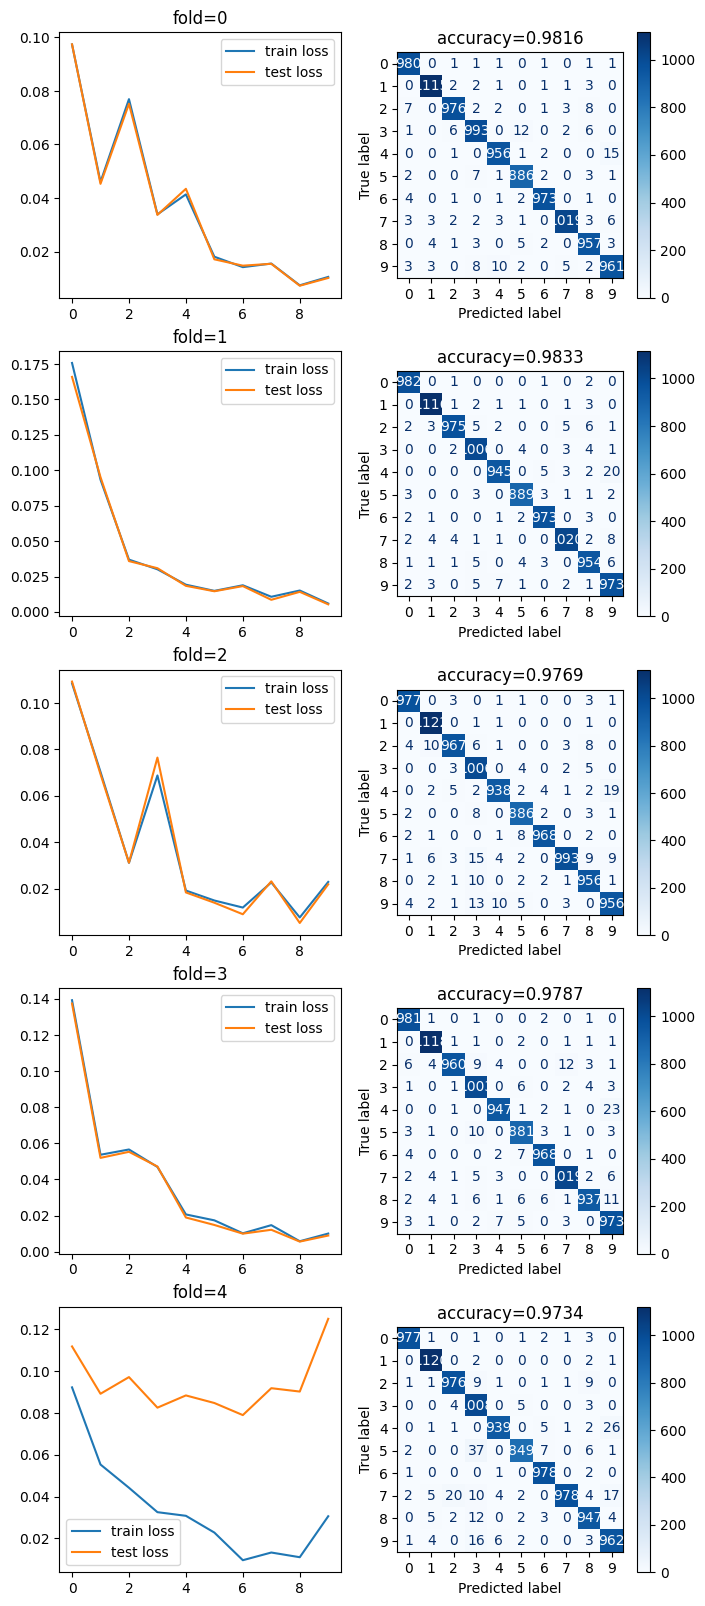

In [49]:
models = best_models

fig, axs = plt.subplots(len(models), 2, figsize=(4*2, 4*len(models)))

for fold, model in enumerate(models):
    ax = axs[fold, 0]
    ax.plot(np.arange(len(model.train_loss_per_epoch)), model.train_loss_per_epoch, label="train loss")
    ax.plot(np.arange(len(model.test_loss_per_epoch)), model.test_loss_per_epoch, label="test loss")
    ax.legend()
    ax.set_title(f"{fold=}")

    ax = axs[fold, 1]
    with torch.no_grad():
        y_pred = model(X_test)
        y_pred = np.argmax(y_pred.detach().cpu(), axis=1)
        accuracy = accuracy_score(y_pred, y_test)

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues", ax=ax)
    ax.set_title(f"{accuracy=}")

plt.show()